# Distributed Quantum Compiler — Demo

This notebook walks through the **entire** memQ distributed-compilation
workflow — compile, verify, schedule — and shows just how little code it
takes:

```
OpenQASM circuit + network topology
        │  compile
        ▼
   distributed OpenQASM  ──►  verify  (circuit equivalence)
        │  schedule
        ▼
     execution schedule
```

The whole workflow is driven by two objects, and they are the only things we
import:

> **Running this notebook.** From the repository root:
>
> ```bash
> uv sync
> uv run jupyter lab demo/demo.ipynb
> ```
>
> Every path below is relative to this `demo/` directory, which is the
> kernel's working directory when the notebook is opened this way. The inputs
> live in `inputs/`; each step writes its artifacts to `outputs/`.

In [1]:
from memq_dqc import Compiler, Scheduler

## 1. Inputs

The compiler takes two plain-text inputs, both in `inputs/`:

1. **A circuit** — an OpenQASM 3.0 file. Here, a 4-qubit Quantum Fourier
   Transform (`qft_n4.qasm`).
2. **A network topology** — a JSON file. Here, `demo_network`: two QPUs
   (`P0`, `P1`), each with 2 computation + 2 communication qubits, linked by a
   remote (entanglement) connection between their communication qubits.

The topology is sketched below:

![Network topology](inputs/demo_network.png)

The input circuit:

In [2]:
print(open("inputs/qft_n4.qasm").read())

OPENQASM 3.0;
include "stdgates.inc";
bit[4] c;
qubit[4] q;
x q[0];
x q[2];
barrier q[0], q[1], q[2], q[3];
h q[0];
cp(pi/2) q[1], q[0];
h q[1];
cp(pi/4) q[2], q[0];
cp(pi/2) q[2], q[1];
h q[2];
cp(pi/8) q[3], q[0];
cp(pi/4) q[3], q[1];
cp(pi/2) q[3], q[2];
h q[3];
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
c[3] = measure q[3];



## 2. Compile

This is the whole compilation step — **two calls**. `Compiler` takes the
circuit and the network directly (file paths, as here, or in-memory objects /
inline QASM source), then `compile()` partitions the circuit's logical qubits
across QPUs and reconstructs a distributed circuit that inserts the network
primitives needed to run two-qubit gates across QPUs.

(`Compiler` is the convenient front end; it drives the lower-level
`Partitioner` for you. `Partitioner` stays available — `from memq_dqc import
Partitioner` — if you want direct control over the partitioning step.)

In [3]:
compiler = Compiler(
    "inputs/qft_n4.qasm", "inputs/demo_network.json", algo="interaction"
)
compiler.compile()

print(
    "network:",
    compiler.network.num_qpus,
    "QPUs |",
    compiler.network.num_comp_qubits,
    "computation +",
    compiler.network.num_comm_qubits,
    "communication qubits",
)

network: 2 QPUs | 4 computation + 4 communication qubits


The distributed circuit is a standard OpenQASM 3.0 program — the
compiler's primary output. We can read it as a string (`distributed_qasm`) and
write it to disk (`save_distributed_circuit`). Note the per-QPU data registers
(`q0`, `q1`), the matching communication registers (`c0`, `c1`), and the
`catent` → remote-gate → `catdisent` sequences that implement each cross-QPU
gate.

In [4]:
compiler.save_distributed_circuit("outputs/qft_n4_distributed.qasm")
print(compiler.distributed_qasm)

OPENQASM 3.0;
include "builder/distgates.inc";
include "stdgates.inc";
qubit[2] q0;
qubit[2] q1;
qubit[2] c0;
qubit[2] c1;
bit[4] c;
x q1[0];
x q0[1];
h q1[0];
catent q0[0], q1[0], c0[0], c1[0];
rcp(pi / 2) q0[0], q1[0], c0[0], c1[0];
catdisent q0[0], q1[0], c0[0], c1[0];
h q0[0];
swap q1[0], q1[1];
catent q0[1], q1[1], c0[1], c1[1];
rcp(pi / 4) q0[1], q1[1], c0[1], c1[1];
catdisent q0[1], q1[1], c0[1], c1[1];
cp(pi / 2) q0[1], q0[0];
h q0[1];
cp(pi / 8) q1[0], q1[1];
catent q1[0], q0[0], c1[0], c0[0];
rcp(pi / 4) q1[0], q0[0], c1[0], c0[0];
catdisent q1[0], q0[0], c1[0], c0[0];
swap q1[0], q1[1];
catent q1[1], q0[1], c1[1], c0[1];
rcp(pi / 2) q1[1], q0[1], c1[1], c0[1];
catdisent q1[1], q0[1], c1[1], c0[1];
h q1[1];
c[0] = measure q1[0];
c[1] = measure q0[0];
c[2] = measure q0[1];
c[3] = measure q1[1];



## 3. The network primitives

The distributed circuit uses a handful of custom gates that stand in for the
networking operations a distributed quantum computer must perform. They fall
into two groups:

- **Remote gates** — `rcx`, `rcp`, `rcz`, `rcry` carry out a two-qubit gate
  between data qubits that physically live on **different** QPUs, without ever
  moving those data qubits. `rswap` performs **state teleportation**, actually
  moving a qubit's state from one QPU to another.
- **Cat-entanglement** — every remote gate is wrapped in a cat-entanglement
  (`catent`) / cat-disentanglement (`catdisent`) pair. `catent` shares the
  control qubit's state across an entangled pair of communication qubits (one
  on each QPU) using a shared EPR pair ("ebit"); the remote gate is then
  applied on the target QPU; and `catdisent` reverses the entanglement,
  leaving the control qubit's state back on its home QPU. The net effect is a
  two-qubit gate across QPUs that never relocates the underlying data qubits.

![Cat-entanglement and cat-disentanglement](catent_disent.jpg)

*Cat-entanglement (`catent`) distributes a data qubit's control across the two
QPUs using a shared entangled pair; cat-disentanglement (`catdisent`) reverses
it once the remote gate has been applied. Figure adapted from Barral et al.*

Because these gates are not part of standard OpenQASM, the distributed program
opens with `include "builder/distgates.inc";` — a **dedicated include file**
that ships with the library and declares every network primitive, kept
separate from the standard `stdgates.inc`. Its gate signatures (bodies are
identity placeholders) are:

```text
// remote two-qubit gates: data_a, data_b, comm_a, comm_b
gate rcx  q0, q1, c0, c1 { ... }
gate rcp  q0, q1, c0, c1 theta { ... }
gate rcry q0, q1, c0, c1 theta { ... }
gate rcz  q0, q1, c0, c1 { ... }

// state teleportation: two data qubits + two comm-qubit pairs
gate rswap q0, q1, c0a, c1a, c0b, c1b { ... }

// cat-entanglement / disentanglement
gate catent    data_a, data_b, comm_a, comm_b { ... }
gate catdisent data_a, data_b, comm_a, comm_b { ... }
```

## 4. Verify

Is the distributed circuit still correct? `compiler.verify()` checks it
directly — no need to re-supply the original circuit, since the compiler
already has it. Under the hood it rewrites the distributed circuit into an
equivalent **monolithic** circuit (each remote gate replaced by its local
equivalent — `rcx`→`cx`, `rcp`→`cp`, …, `rswap`→`swap` — and the entanglement
scaffolding dropped), simulates both the original and the rewritten circuit,
and compares their output distributions via **Hellinger fidelity**. `shots` and
`verbosity` are optional.

In [5]:
print("verified:", compiler.verify(shots=20000, verbosity="info"))

2026-08-18 17:48:39 | INFO | memq_dqc.verify.verify | Starting distributed circuit verification: method=sampling shots=20000 fidelity_threshold=0.900.


2026-08-18 17:48:39 | INFO | memq_dqc.verify.verify | Verification succeeded in 0.089s: fidelity=0.999612 threshold=0.900000.


verified: True


## 5. Schedule

Finally, the `Scheduler` lays the distributed circuit's operations out on a
timeline — respecting data dependencies, communication-qubit availability, and
how long each operation takes on real hardware — aiming to minimize the
**makespan** (total execution time). Hand it the `compiler` directly. The
hardware is chosen with two strings: a *modality* (here `neutral_atom`, which
sets local gate times) and an *entanglement profile* (here an illustrative
`demo.demo`, which sets the entanglement-generation rate).

In [6]:
scheduler = Scheduler(
    compiler,
    algo="des_link_fifo",
    modality="neutral_atom",
    entanglement_profile="demo.demo",
    algo_kwargs={"seed": 0},
)
scheduler.run()

print(
    "makespan:",
    round(scheduler.schedule.makespan, 1),
    "µs |",
    "scheduled events:",
    len(scheduler.schedule.operations),
)

makespan: 93.8 µs | scheduled events: 30


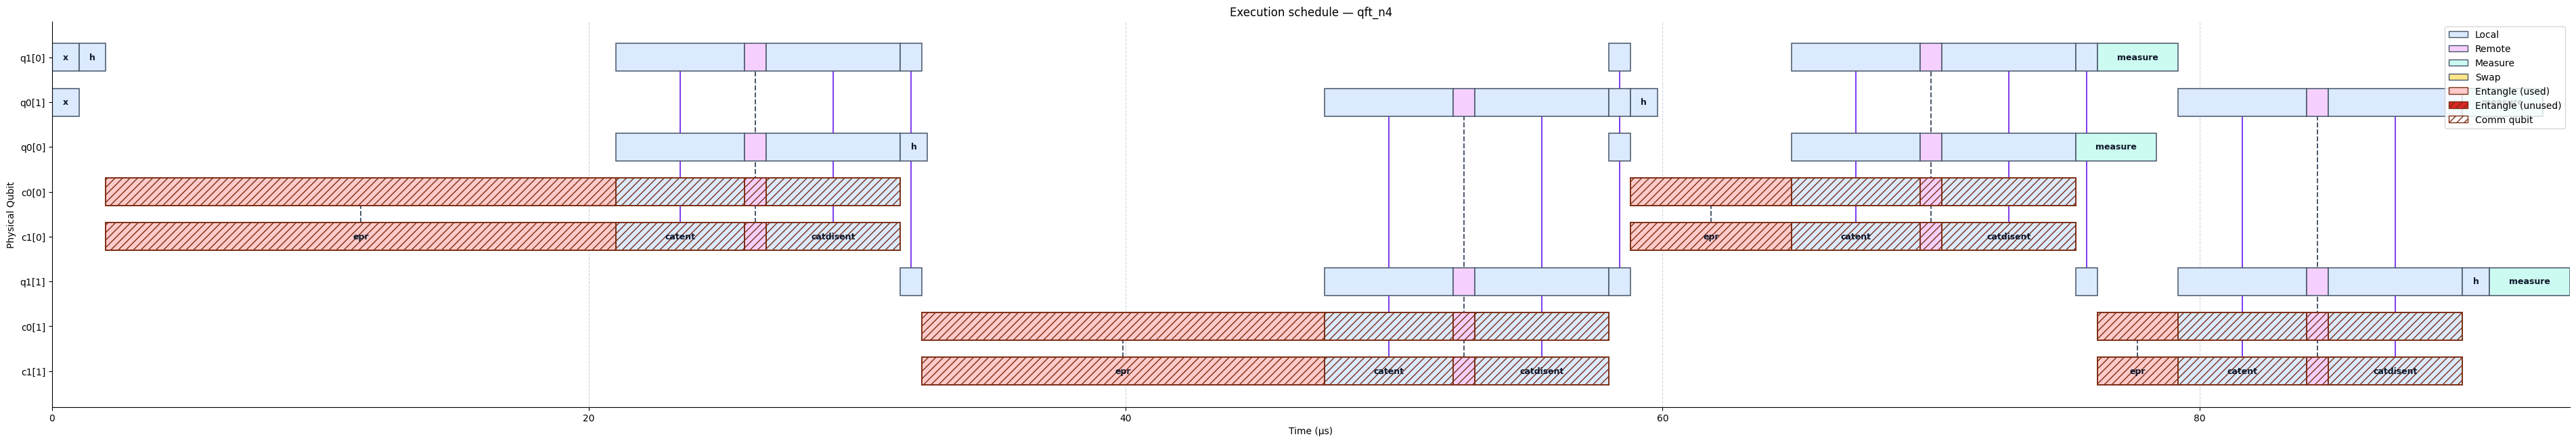

In [7]:
scheduler.plot_gantt(
    title="Execution schedule — qft_n4",
    display="legacy",
    save_path="outputs/schedule_gantt.png",
);

Each row is a physical qubit. The communication qubits (`c…`) generate
entanglement (`epr`) and run the `catent`/`catdisent` halves of each remote
gate, while the data qubits (`q…`) carry the local gates and final
measurements.

## What you produced

From two plain-text inputs and a handful of lines — importing nothing but
`Compiler` and `Scheduler` — the workflow produced:

| File | What it is |
| --- | --- |
| `outputs/qft_n4_distributed.qasm` | The distributed circuit — standard OpenQASM 3.0 |
| `outputs/schedule_gantt.png` | The execution-schedule Gantt chart |

…plus a verification check confirming the distributed circuit is behaviorally
equivalent to the original.